# Prophet 时序预测——零售需求（含协变量）

使用 Facebook Prophet 预测门店下一季度（13周）的周销售额，以 **Open**、**Promo**、**SchoolHoliday**、**StateHoliday** 作为已知未来协变量，并与不含协变量的基线对比。

数据：AutoGluon retail_sales（Rossmann 门店销售，周频，门店 ID = "1"）

预测步长：13 周

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from prophet import Prophet

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

TIMESERIES_ID     = '1'
PREDICTION_LENGTH = 13
SHOW_HISTORY      = 104  # 展示最近 104 周（约 2 年）历史数据

sales_context_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet',
    engine='fastparquet'
)
sales_context_df['timestamp'] = pd.to_datetime(sales_context_df['timestamp'])

sales_test_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet',
    engine='fastparquet'
)
sales_test_df['timestamp'] = pd.to_datetime(sales_test_df['timestamp'])

print('训练数据:', sales_context_df.shape, '| 列:', list(sales_context_df.columns))
print(f'时间范围: {sales_context_df["timestamp"].min().date()} ~ {sales_context_df["timestamp"].max().date()}')
print('预测期:',  sales_test_df['timestamp'].min().date(), '~', sales_test_df['timestamp'].max().date())
sales_context_df.head(3)

训练数据: (133800, 8) | 列: ['id', 'timestamp', 'Sales', 'Open', 'Promo', 'SchoolHoliday', 'StateHoliday', 'Customers']
时间范围: 2013-01-13 ~ 2015-04-26
预测期: 2015-05-03 ~ 2015-07-26


,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0


In [2]:
# 过滤门店 1，重命名列；已知未来协变量包括 Open/Promo/SchoolHoliday/StateHoliday
FUTURE_COVS = ['Open', 'Promo', 'SchoolHoliday', 'StateHoliday']

df_context = (
    sales_context_df[sales_context_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds', 'Sales': 'y'})
    [['ds', 'y'] + FUTURE_COVS]
    .reset_index(drop=True)
)

df_future_cov = (
    sales_test_df[sales_test_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds'})
    [['ds'] + FUTURE_COVS]
    .reset_index(drop=True)
)

print(f'历史上下文: {len(df_context)} 行  ({df_context["ds"].min().date()} ~ {df_context["ds"].max().date()})')
print(f'未来协变量: {len(df_future_cov)} 行  ({df_future_cov["ds"].iloc[0].date()} ~ {df_future_cov["ds"].iloc[-1].date()})')
df_context.tail(3)

历史上下文: 120 行  (2013-01-13 ~ 2015-04-26)
未来协变量: 13 行  (2015-05-03 ~ 2015-07-26)


,ds,y,Open,Promo,SchoolHoliday,StateHoliday
117,2015-04-12,19546.0,0.714286,0.000000,5.0,1.0
118,2015-04-19,27563.0,0.857143,0.714286,0.0,0.0
119,2015-04-26,20670.0,0.857143,0.000000,0.0,0.0


In [3]:
# 训练 Prophet 模型（含协变量）
m_with_cov = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    interval_width=0.8,
)
for col in FUTURE_COVS:
    m_with_cov.add_regressor(col)

m_with_cov.fit(df_context)
print('Prophet 模型训练完成（含协变量）')

10:45:59 - cmdstanpy - INFO - Chain [1] start processing
10:45:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet 模型训练完成（含协变量）


In [4]:
# 预测：拼接历史时间戳（含协变量）+ 未来 13 周协变量
df_pred_input  = pd.concat([df_context[['ds'] + FUTURE_COVS], df_future_cov], ignore_index=True)
forecast_w_cov = m_with_cov.predict(df_pred_input)
future_w_cov   = forecast_w_cov.tail(PREDICTION_LENGTH)

print('预测完成')
future_w_cov[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

预测完成


,ds,yhat,yhat_lower,yhat_upper
120,2015-05-03,26968.614991,24557.102544,29319.523182
121,2015-05-10,28763.304876,26219.870640,31391.328691
122,2015-05-17,21648.594904,19213.315855,24188.741393
123,2015-05-24,29000.035482,26412.158641,31428.825963
124,2015-05-31,20636.572183,18157.979223,23190.092152
125,2015-06-07,26821.217876,24390.184068,29262.339298
126,2015-06-14,21589.798414,19047.259791,24276.786701
127,2015-06-21,28703.487969,26406.125154,31089.641178
128,2015-06-28,22399.262417,19891.497878,24834.254153
129,2015-07-05,28993.082027,26499.495238,31501.895295


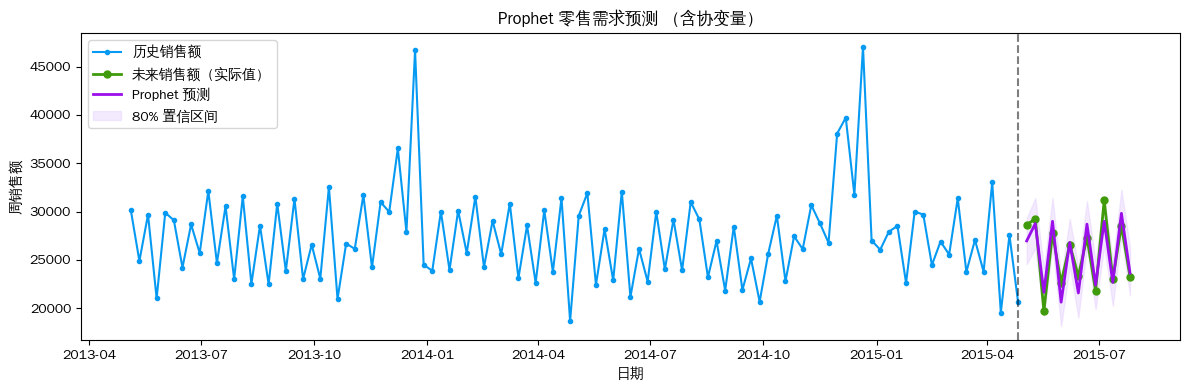

In [5]:
def plot_prophet_retail(df_context, future_forecast, sales_test_df,
                        timeseries_id, title_suffix=''):
    df_hist = df_context.tail(SHOW_HISTORY)
    df_gt   = (sales_test_df[sales_test_df['id'] == timeseries_id]
               .rename(columns={'timestamp': 'ds'}))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_hist['ds'], df_hist['y'],
            label='历史销售额', color='xkcd:azure', marker='o', markersize=3)
    ax.plot(df_gt['ds'], df_gt['Sales'],
            label='未来销售额（实际值）', color='xkcd:grass green', marker='o', markersize=5, linewidth=2)
    ax.plot(future_forecast['ds'], future_forecast['yhat'],
            label='Prophet 预测', color='xkcd:violet', linewidth=2)
    ax.fill_between(future_forecast['ds'],
                    future_forecast['yhat_lower'], future_forecast['yhat_upper'],
                    alpha=0.35, label='80% 置信区间', color='xkcd:light lavender')
    ax.axvline(x=df_context['ds'].max(), color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'Prophet 零售需求预测 {title_suffix}')
    ax.set_xlabel('日期')
    ax.set_ylabel('周销售额')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_prophet_retail(df_context, future_w_cov, sales_test_df,
                    TIMESERIES_ID, title_suffix='（含协变量）')

10:46:09 - cmdstanpy - INFO - Chain [1] start processing
10:46:09 - cmdstanpy - INFO - Chain [1] done processing


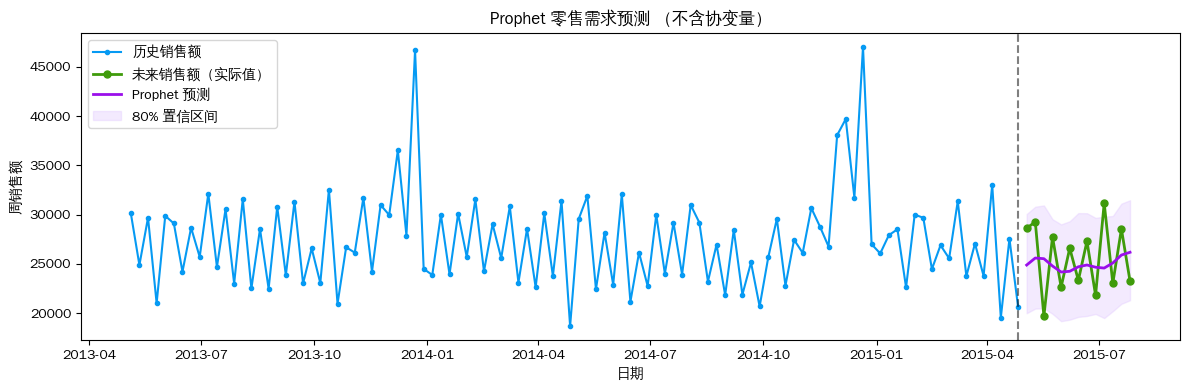

In [6]:
# 对比：不含协变量的基线
m_no_cov = Prophet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    seasonality_mode='multiplicative', interval_width=0.8,
)
m_no_cov.fit(df_context[['ds', 'y']])

future_no_cov_input = m_no_cov.make_future_dataframe(periods=PREDICTION_LENGTH, freq='W')
forecast_no_cov     = m_no_cov.predict(future_no_cov_input)
future_no_cov       = forecast_no_cov.tail(PREDICTION_LENGTH)

plot_prophet_retail(df_context, future_no_cov, sales_test_df,
                    TIMESERIES_ID, title_suffix='（不含协变量）')

In [7]:
# 误差指标对比
gt = (sales_test_df[sales_test_df['id'] == TIMESERIES_ID]
      .sort_values('timestamp')['Sales'].values)

def calc_metrics(y_true, y_pred, label):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label}  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.2f}%')

print('─' * 55)
calc_metrics(gt, future_w_cov['yhat'].values,  'Prophet 含协变量:  ')
calc_metrics(gt, future_no_cov['yhat'].values, 'Prophet 不含协变量:')
print('─' * 55)

───────────────────────────────────────────────────────
Prophet 含协变量:    MAE=1194.1  RMSE=1372.6  MAPE=4.74%
Prophet 不含协变量:  MAE=3147.3  RMSE=3475.1  MAPE=12.39%
───────────────────────────────────────────────────────
